In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

# Load Pima Indians Diabetes dataset
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)

# Extract standard continuous features
X_pima = pima_df[pima_cols[:-1]]
y_pima = pima_df['Outcome']

print("Pima Dataset Shape (rows, cols):", pima_df.shape)
print("\nClass Outcome Distribution:")
print(pima_df['Outcome'].value_counts())


Pima Dataset Shape (rows, cols): (768, 9)

Class Outcome Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Perform Stratified Train-Test Split
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pima, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

# Train a baseline Random Forest Classifier
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train_p, y_train_p)

# Evaluate holdout test accuracy
holdout_preds = rf_baseline.predict(X_test_p)
holdout_accuracy = accuracy_score(y_test_p, holdout_preds)

print(f"Stratified Holdout (Train-Test Split) Accuracy: {holdout_accuracy * 100:.2f}%")


Stratified Holdout (Train-Test Split) Accuracy: 75.97%


In [3]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Initialize 10-Fold Stratified CV Strategy
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Compute cross-validation scores using baseline Random Forest
cv_scores = cross_val_score(rf_baseline, X_pima, y_pima, cv=cv_strategy, scoring='accuracy')

print("10-Fold Stratified CV Accuracy Scores:")
print(cv_scores.round(4))
print(f"\nMean Cross-Validation Accuracy Score: {cv_scores.mean() * 100:.2f}%")
print(f"Standard Deviation of CV Accuracy:     {cv_scores.std() * 100:.2f}%")


10-Fold Stratified CV Accuracy Scores:
[0.8052 0.7532 0.7143 0.8701 0.7922 0.7273 0.7532 0.7662 0.7895 0.7237]

Mean Cross-Validation Accuracy Score: 76.95%
Standard Deviation of CV Accuracy:     4.45%


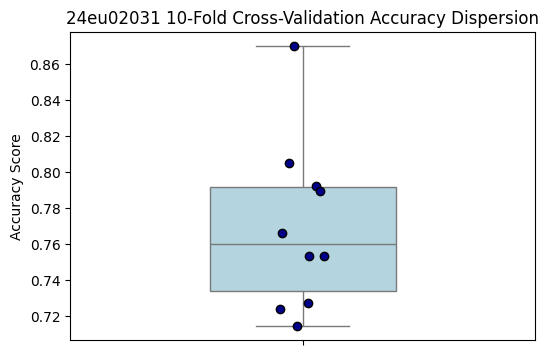

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot cross-validation score dispersion
plt.figure(figsize=(6, 4))
sns.boxplot(y=cv_scores, color='lightblue', width=0.4)
sns.stripplot(y=cv_scores, color='darkblue', size=6, jitter=0.05, edgecolor='black', linewidth=1)
plt.title("24eu02031 10-Fold Cross-Validation Accuracy Dispersion")
plt.ylabel("Accuracy Score")
plt.show()


In [5]:
# Compile comparison table
validation_comparison = pd.DataFrame({
    'Validation Strategy': ['Holdout Stratified (80/20 Split)', '10-Fold Stratified Cross-Validation (Mean)'],
    'Accuracy Score (%)': [holdout_accuracy * 100, cv_scores.mean() * 100],
    'Score Std Deviation (%)': [0.0, cv_scores.std() * 100]
})

print("--- Validation Strategy Trade-offs ---")
print(validation_comparison.to_string(index=False))


--- Validation Strategy Trade-offs ---
                       Validation Strategy  Accuracy Score (%)  Score Std Deviation (%)
          Holdout Stratified (80/20 Split)           75.974026                 0.000000
10-Fold Stratified Cross-Validation (Mean)           76.949761                 4.448026


In [6]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Sonar dataset
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
sonar_features = [f"F_{i}" for i in range(1, 61)]
sonar_columns = sonar_features + ['Class']
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

# Encode class: M -> 1, R -> 0
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

X_sonar = sonar_df[sonar_features]
y_sonar = sonar_df['Class_numeric']

# Scale features
scaler_sonar = StandardScaler()
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

# Split into train/test sets
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

print("Sonar Training Set Shape:", X_train_s.shape)
print("Sonar Test Set Shape:", X_test_s.shape)


Sonar Training Set Shape: (145, 60)
Sonar Test Set Shape: (63, 60)


In [7]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Train baseline SVM classifier with default settings
svm_default = SVC(probability=True, random_state=42)
svm_default.fit(X_train_s, y_train_s)

# Evaluate baseline accuracy
default_preds = svm_default.predict(X_test_s)
default_accuracy = accuracy_score(y_test_s, default_preds)

print(f"Default SVM Test Accuracy: {default_accuracy * 100:.2f}%")


Default SVM Test Accuracy: 84.13%


In [8]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for SVM
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf']
}

# Run Grid Search Cross-Validation
grid_search = GridSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train_s, y_train_s)

# Extract optimized model and predict
best_svm_grid = grid_search.best_estimator_
grid_preds = best_svm_grid.predict(X_test_s)
grid_accuracy = accuracy_score(y_test_s, grid_preds)

print("Optimal Hyperparameters Selected via Grid Search:", grid_search.best_params_)
print(f"Grid-Search Optimized SVM Test Accuracy: {grid_accuracy * 100:.2f}%")


Optimal Hyperparameters Selected via Grid Search: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Grid-Search Optimized SVM Test Accuracy: 92.06%


In [9]:
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distributions
param_distributions = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf']
}

# Run Randomized Search Cross-Validation (evaluating 10 random candidates)
random_search = RandomizedSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_distributions=param_distributions,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train_s, y_train_s)

# Extract optimized model and predict
best_svm_random = random_search.best_estimator_
random_preds = best_svm_random.predict(X_test_s)
random_accuracy = accuracy_score(y_test_s, random_preds)

print("Optimal Hyperparameters Selected via Randomized Search:", random_search.best_params_)
print(f"Randomized-Search Optimized SVM Test Accuracy: {random_accuracy * 100:.2f}%")


Optimal Hyperparameters Selected via Randomized Search: {'kernel': 'rbf', 'gamma': 0.01, 'C': 1}
Randomized-Search Optimized SVM Test Accuracy: 79.37%


--- Hyperparameter Optimization Comparison ---
                Tuning Strategy  Test Accuracy (%)
         Default Parameters SVM          84.126984
      Grid-Search Optimized SVM          92.063492
Randomized-Search Optimized SVM          79.365079


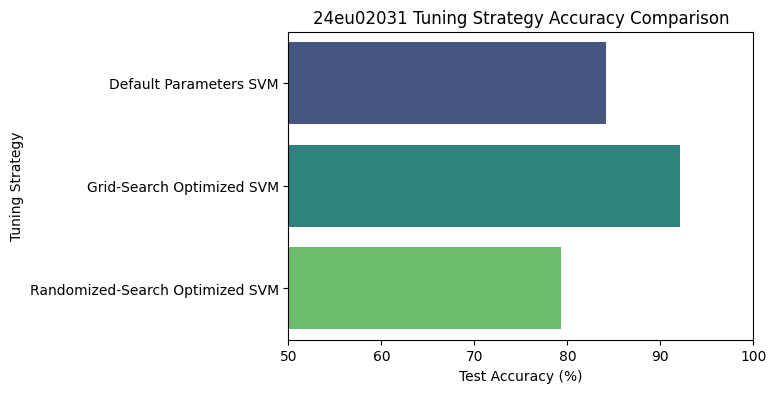

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compile results
optimization_results = pd.DataFrame({
    'Tuning Strategy': ['Default Parameters SVM', 'Grid-Search Optimized SVM', 'Randomized-Search Optimized SVM'],
    'Test Accuracy (%)': [default_accuracy * 100, grid_accuracy * 100, random_accuracy * 100]
})

print("--- Hyperparameter Optimization Comparison ---")
print(optimization_results.to_string(index=False))

# Plot comparative bar chart
plt.figure(figsize=(6, 4))
sns.barplot(data=optimization_results, x='Test Accuracy (%)', y='Tuning Strategy', palette='viridis')
plt.xlim([50, 100])
plt.title("24eu02031 Tuning Strategy Accuracy Comparison")
plt.show()


1. BASELINE K-FOLD CROSS-VALIDATION
  Fold 1 Accuracy: 0.8156
  Fold 2 Accuracy: 0.7921
  Fold 3 Accuracy: 0.8202
  Fold 4 Accuracy: 0.8202
  Fold 5 Accuracy: 0.8258

Mean Baseline Accuracy: 0.8148 (± 0.0118)

2. GRID SEARCH TUNING
Tuned Best Model Fold Scores:
  Fold 1 Accuracy: 0.8268
  Fold 2 Accuracy: 0.8315
  Fold 3 Accuracy: 0.8258
  Fold 4 Accuracy: 0.8483
  Fold 5 Accuracy: 0.8596

Best Cross-Validation Accuracy: 0.8384

Best Parameters Found:
  max_depth: 8
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 100

--- Out-of-Fold Classification Report ---
              precision    recall  f1-score   support

    Perished       0.84      0.91      0.87       549
    Survived       0.83      0.73      0.78       342

    accuracy                           0.84       891
   macro avg       0.84      0.82      0.82       891
weighted avg       0.84      0.84      0.84       891



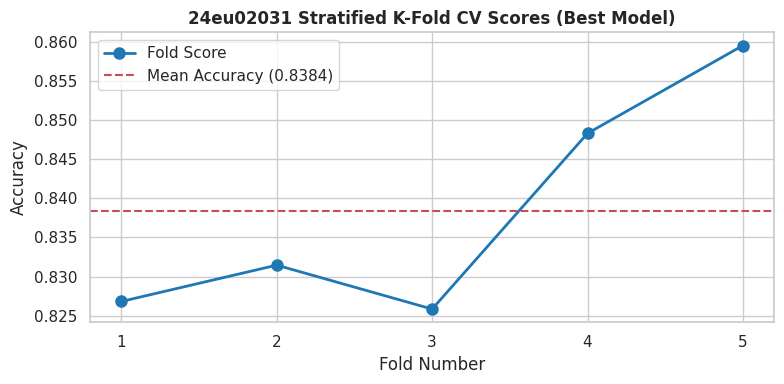

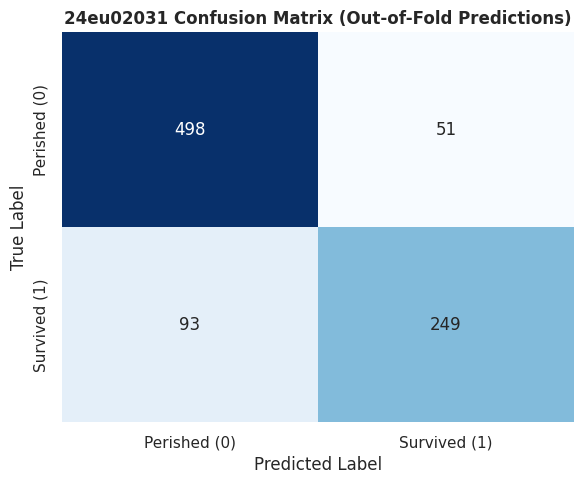

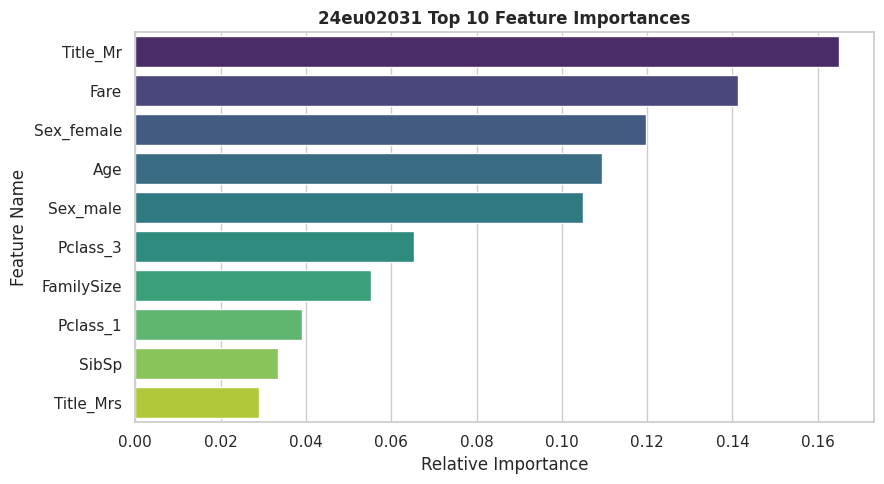

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Set visual style for plots
sns.set_theme(style="whitegrid")

# ==========================================
# 1. LOAD DATA & FEATURE ENGINEERING
# ==========================================
URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(URL)

# Title Extraction
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
df["Title"] = df["Title"].replace(
    [
        "Lady",
        "Countess",
        "Capt",
        "Col",
        "Don",
        "Dr",
        "Major",
        "Rev",
        "Sir",
        "Jonkheer",
        "Dona",
    ],
    "Rare",
).replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

# Family Features
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# Feature Selection
num_features = ["Age", "Fare", "SibSp", "Parch", "FamilySize"]
cat_features = ["Pclass", "Sex", "Embarked", "Title", "IsAlone"]

X = df[num_features + cat_features]
y = df["Survived"]

# ==========================================
# 2. PREPROCESSING PIPELINES
# ==========================================
num_transformer = Pipeline(
    [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

cat_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features),
    ]
)

# Set up Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42)),
    ]
)

# ==========================================
# 3. BASELINE K-FOLD CROSS-VALIDATION
# ==========================================
print("==========================================")
print("1. BASELINE K-FOLD CROSS-VALIDATION")
print("==========================================")

baseline_scores = cross_val_score(clf_pipeline, X, y, cv=skf, scoring="accuracy")

for fold_idx, score in enumerate(baseline_scores, 1):
    print(f"  Fold {fold_idx} Accuracy: {score:.4f}")

print(
    f"\nMean Baseline Accuracy: {baseline_scores.mean():.4f} (± {baseline_scores.std():.4f})"
)

# ==========================================
# 4. GRID SEARCH HYPERPARAMETER TUNING
# ==========================================
print("\n==========================================")
print("2. GRID SEARCH TUNING")
print("==========================================")

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [4, 6, 8],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
}

grid_search = GridSearchCV(
    estimator=clf_pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1,
)

grid_search.fit(X, y)
best_model = grid_search.best_estimator_

# Retrieve individual fold scores for the tuned best model
best_model_fold_scores = [
    grid_search.cv_results_[f"split{i}_test_score"][grid_search.best_index_]
    for i in range(5)
]

print("Tuned Best Model Fold Scores:")
for fold_idx, score in enumerate(best_model_fold_scores, 1):
    print(f"  Fold {fold_idx} Accuracy: {score:.4f}")

print(f"\nBest Cross-Validation Accuracy: {grid_search.best_score_:.4f}")
print("\nBest Parameters Found:")
for param, val in grid_search.best_params_.items():
    print(f"  {param.split('__')[1]}: {val}")

# Out-of-fold predictions and classification report
y_pred = cross_val_predict(best_model, X, y, cv=skf)

print("\n--- Out-of-Fold Classification Report ---")
print(classification_report(y, y_pred, target_names=["Perished", "Survived"]))

# ==========================================
# 5. VISUALIZATIONS
# ==========================================

# Figure 1: Stratified K-Fold Accuracy Scores Across Folds
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, 6),
    best_model_fold_scores,
    marker="o",
    linewidth=2,
    markersize=8,
    color="#1f77b4",
    label="Fold Score",
)
plt.axhline(
    y=np.mean(best_model_fold_scores),
    color="r",
    linestyle="--",
    label=f"Mean Accuracy ({np.mean(best_model_fold_scores):.4f})",
)
plt.title(
    "24eu02031 Stratified K-Fold CV Scores (Best Model)", fontsize=12, fontweight="bold"
)
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.xticks(range(1, 6))
plt.legend()
plt.tight_layout()
plt.show()

# Figure 2: Confusion Matrix Heatmap
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Perished (0)", "Survived (1)"],
    yticklabels=["Perished (0)", "Survived (1)"],
)
plt.title(
    "24eu02031 Confusion Matrix (Out-of-Fold Predictions)", fontsize=12, fontweight="bold"
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Figure 3: Top Feature Importances
encoded_cat_cols = (
    best_model.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(cat_features)
)
feature_names = num_features + list(encoded_cat_cols)
importances = best_model.named_steps["classifier"].feature_importances_

feat_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(data=feat_df, x="Importance", y="Feature", palette="viridis")
plt.title("24eu02031 Top 10 Feature Importances", fontsize=12, fontweight="bold")
plt.xlabel("Relative Importance")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()